# Hledání hnacích faktorů denní poptávky po elektřině pomocí výběru proměnných GLM


## Shrnutí

Tento notebook sestavuje zobecněný lineární model poptávky po elektřině pro denní spotřebu na jedno měřidlo (kWh) v závislosti na počasí, nemovitosti a tarifních faktorech a používá automatizovaný **výběr proměnných** k oddělení skutečně důležitých prediktorů od uměle vložených šumových proměnných. Na syntetickém vzorku 100 měřidel spouští:

- Dopřednou selekci **PROC GLMSELECT** (zastavenou pomocí SBC) a adaptivní kontrolu LASSO na `log(kwh)`,
- Poissonovy a negativně binomické count modely s logaritmickým spojením **PROC GENMOD**, s odhady maximální věrohodnosti a reziduální diagnostikou,
- nasaditelný artefakt **skórovacího kódu** vygenerovaný z vybraného modelu.

Každé číslo uvedené níže je přečteno přímo ze spuštěného výstupu. Dopředná selekce podle SBC ponechává **osm efektů** a odmítá **oba** uměle vložené šumové proměnné, čímž dosahuje R-kvadrát **0,9418**. Poissonův model odhaluje fyzikálně smysluplná znaménka - střešní solární panely a (slabě) cena stahují poptávku dolů; denostupně, velikost nemovitosti, obsazenost a komerční/průmyslové tarifní třídy ji zvyšují - a přepočet na negativně binomický model ukazuje, že vzorek **není** materiálně přerozptýlený (jeho AIC je mírně *horší* než u Poissonova modelu), což vyvrací obvyklý reflex sáhnout po parametru rozptýlení.


## Poznámka k proceduře

V SAS/STAT je **PROC HPGENSELECT** vysoce výkonná procedura, která v jednom kroku fituje zobecněný lineární model *a* vybírá efekty. Na enginu Jenner, který pohání tento notebook, HPGENSELECT zatím není implementován, takže analýza je realizována na jeho dvou zavedených SAS-kompatibilních stavebních blocích, které společně pokrývají stejný pracovní postup:

| Cíl | Zde použitá procedura |
|------|---------------------|
| Automatizovaný výběr efektů (dopředný, LASSO) se zastavením podle informačního kritéria, validačním seedem a generováním skórovacího kódu | **PROC GLMSELECT** |
| Count odpověď s logaritmickým spojením, odhady maximální věrohodnosti, řešení přerozptýlení a reziduální diagnostika | **PROC GENMOD** |

Mezera v HPGENSELECT je sledována uloženým regresním testem
(`tests/400922_nb_hpgenselect_stub_emits_no_real_glm_selection_results`);
až bude procedura implementována, stejnou analýzu bude možné vyjádřit jako jediné volání HPGENSELECT.


## Zdroje dat

| Datový soubor | Řádky | Popis | Klíčové proměnné |
|---------|------|-------------|---------------|
| `utility_demand` | 100 | Syntetický vzorek chytrých měřidel pro jeden zúčtovací den, vygenerovaný přímo pomocí `call streaminit(70291)` a `rand()`. Denní spotřeba je Poissonův výběr, jehož logaritmický průměr závisí na počasí, velikosti nemovitosti, obsazenosti, solárních panelech, tarifu a třídě sazby. | `meter_id`, `RateClass` (Residential/Commercial/Industrial), `Region` (North/South/Coast), `hdd`/`cdd` (denostupně vytápění/chlazení), `sqft`, `occupants`, `solar_kw` (výkon střešní fotovoltaiky v kW), `appliances`, `price_kwh` (mezní tarif), `noise1`/`noise2` (irelevantní rušivé prediktory), `kwh_day` (odpověď: denní kWh, count) |

Nelicencovaný běhový engine Jenner omezuje výstup na 100 pozorování, takže generující smyčka je nastavena přesně na 100 měřidel a každá statistika níže je počítána z tohoto vzorku.


## Krok 1 - Vygenerování syntetického vzorku chytrých měřidel

Simulujeme 100 měřidel pro jeden zúčtovací den. *Skutečný* proces dělá z `kwh_day` Poissonův výběr, jehož logaritmický průměr roste s denostupni vytápění a chlazení, velikostí nemovitosti, obsazeností a počtem spotřebičů a klesá se solární kapacitou na místě a mezní cenou za kWh. Komerční a (ještě více) průmyslové nemovitosti spotřebují více; pobřežní nemovitosti o něco méně. Dva prediktory, `noise1` a `noise2`, jsou čistý šum - výběr by je měl *odmítnout*, což ověříme později.


In [1]:
data utility_demand;
   CALL streaminit(70291);
   DÉLKA RateClass $12 Region $5;
   OPAKUJ meter_id = 1 TO 100;
      /* Rate class mix: mostly residential */
      u = rand("uniform");
      KDYŽ      u < 0.45 PAK RateClass = "Residential";
      JINAK KDYŽ u < 0.78 PAK RateClass = "Commercial";
      JINAK                  RateClass = "Industrial";

      /* Service region */
      r = rand("uniform");
      KDYŽ      r < 0.34 PAK Region = "North";
      JINAK KDYŽ r < 0.67 PAK Region = "South";
      JINAK                  Region = "Coast";

      /* Weather and premise drivers */
      hdd        = round(rand("normal", 620, 180));   /* heating degree-days */
      cdd        = round(rand("normal", 540, 160));   /* cooling degree-days */
      sqft       = round(rand("normal", 2200, 700));  /* premise floor area  */
      occupants  = MAX(1, round(rand("poisson", 3))); /* household size      */
      solar_kw   = round(rand("exponential") * 2.5, 0.1); /* rooftop PV kW    */
      appliances = round(rand("normal", 9, 3));       /* major appliances    */
      price_kwh  = round(rand("normal", 0.14, 0.03), 0.001); /* tariff $/kWh  */

      /* Two irrelevant nuisance predictors */
      noise1 = rand("normal");
      noise2 = rand("normal");

      /* True log-mean of daily consumption */
      BASE = 1.6
           + 0.0011*hdd + 0.0013*cdd
           + 0.00018*sqft + 0.10*occupants
           - 0.22*solar_kw + 0.02*appliances
           - 1.4*price_kwh;
      KDYŽ RateClass = "Commercial" PAK BASE = BASE + 0.45;
      KDYŽ RateClass = "Industrial" PAK BASE = BASE + 0.95;
      KDYŽ Region    = "Coast"      PAK BASE = BASE - 0.10;

      lambda  = EXP(BASE);
      kwh_day = rand("poisson", lambda);
      VÝSTUP;
   KONEC;
   ODSTRANIT u r BASE lambda;
SPUSTIT;

PROCEDURA TISK data=utility_demand(obs=10) noobs;
   ŠTÍTEK meter_id='ID měřidla' RateClass='Tarifní třída' Region='Region' hdd='Denostupně vytápění'
         cdd='Denostupně chlazení' sqft='Plocha (sqft)' occupants='Obyvatelé' solar_kw='Solár (kW)'
         appliances='Spotřebiče' price_kwh='Cena (USD/kWh)' kwh_day='Denní spotřeba (kWh)';
   NÁZEV "Ukázka syntetické populace chytrých měřidel";
SPUSTIT;
NÁZEV;

PROCEDURA PRŮMĚRY data=utility_demand n mean MIN MAX;
   PROMĚNNÁ kwh_day hdd cdd sqft occupants solar_kw appliances price_kwh;
   ŠTÍTEK kwh_day='Denní spotřeba (kWh)' hdd='Denostupně vytápění' cdd='Denostupně chlazení'
         sqft='Plocha (sqft)' occupants='Obyvatelé' solar_kw='Solár (kW)' appliances='Spotřebiče'
         price_kwh='Cena (USD/kWh)';
   NÁZEV "Souhrn faktorů napříč vzorkem 100 měřidel";
SPUSTIT;
NÁZEV;


                                      Ukázka syntetické populace chytrých měřidel                                       

   Tarifní třída  Region    ID měřidla      Denostupně vytápění    Denostupně chlazení  Plocha (sqft)   Obyvatelé   Solár (kW)    Spotřebiče  Cena (USD/kWh)         noise1         noise2    Denní spotřeba (kWh)
Residential       North              1                      632                    630           2443           2          9.3            13            0.15   1.5972387728  -0.3994803288                       3
Residential       Coast              2                      701                    449           1014           1          2.5             9           0.166   0.6316273713  -0.4796275662                      14
Residential       North              3                      655                    449           2044           1          1.2             8           0.179   -0.122779194   0.2234944748                      23
Residential       Coast           


NOTE: DATA utility_demand


NOTE: Wrote utility_demand (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=utility_demand

NOTE: PROC PRINT completed: 10 observations printed, 13 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 2 - Dopředná selekce logaritmu poptávky (PROC GLMSELECT)

GLMSELECT je doporučený engine SAS pro výběr efektů. Protože fituje metodou nejmenších čtverců, modelujeme `log_kwh = log(kwh_day + 1)`, což linearizuje multiplikativní faktory, takže každý koeficient se čte jako přibližná proporcionální změna poptávky.

Dvě kategoriální proměnné, `RateClass` a `Region`, jsou uvedeny v příkazu **CLASS**. Výběr řídíme pomocí
`SELECTION=FORWARD(SELECT=SBC STOP=SBC CHOOSE=SBC)`: efekty vstupují jeden po druhém, Schwarzovo bayesovské kritérium vybírá další efekt a také rozhoduje, kdy zastavit, a je zvolen SBC-optimální model. Je nastaveno `SEED=`, aby byl běh reprodukovatelný. Chceme, aby vstoupily skutečné hnací faktory a `noise1`/`noise2` zůstaly mimo.


In [2]:
/* GLMSELECT is a least-squares effect selector, so we model the
   log of daily kWh. log(kwh_day + 1) keeps the (rare) zero-demand
   meter well-defined and linearizes the multiplicative drivers, so a
   coefficient is read as an approximate proportional change in demand. */
data demand_log;
   NASTAVIT utility_demand;
   log_kwh = LOG(kwh_day + 1);
SPUSTIT;

PROCEDURA glmselect data=demand_log seed=12345;
   TŘÍDA RateClass Region;
   MODEL log_kwh = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh noise1 noise2
                 / selection=forward(choose=SBC select=SBC stop=SBC);
   ŠTÍTEK log_kwh='Log(denní kWh)' RateClass='Tarifní třída' Region='Region' hdd='Denostupně vytápění'
         cdd='Denostupně chlazení' sqft='Plocha (sqft)' occupants='Obyvatelé' solar_kw='Solár (kW)'
         appliances='Spotřebiče' price_kwh='Cena (USD/kWh)';
   NÁZEV "Dopředná selekce podle SBC (log denní kWh)";
SPUSTIT;
NÁZEV;


The GLMSELECT Procedure


Dependent Variable: LOG_KWH Log(denní kWh)


Number of Observations Used: 100

               Class Level Information                

    Class    Levels                             Values
---------  --------  ---------------------------------
rateclass         3  Commercial Industrial Residential
   region         3                  Coast North South

                                                       Forward Selection Summary                                                        

    Step    Action                   Effect  Number Effects In  R-Square  Adj R-Sq        AIC       AICC        BIC        SBC      C(p)
--------  --------  -----------------------  -----------------  --------  --------  ---------  ---------  ---------  ---------  --------
       1   Entered               Solár (kW)                  1    0.5367    0.5320  -120.1309  -120.0072  -123.0836  -114.9205  642.0029
       2   Entered     RATECLASS INDUSTRIAL                  2    0.7


NOTE: DATA demand_log


NOTE: Read 100 rows from utility_demand.
NOTE: Wrote demand_log (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC GLMSELECT data=demand_log

NOTE: PROC GLMSELECT statement used.


## Krok 3 - Kontrola hnacích faktorů pomocí adaptivního LASSO

Dopředná selekce je hladová, takže stejnou kandidátní množinu znovu fitujeme s regularizací **LASSO** jako kontrolou robustnosti. `ADAPTIVE` aplikuje na data reagující váhy penalizace (silné efekty jsou penalizovány méně) a `CHOOSE=AICC` vybírá bod na cestě LASSO, který minimalizuje korigované Akaikeho informační kritérium. Porovnání množiny vybrané LASSO s dopřednou množinou nám říká, jak stabilní je zvolená struktura a zda kterákoli z metod není zmatena šumovými sloupci.


In [3]:
PROCEDURA glmselect data=demand_log;
   TŘÍDA RateClass Region;
   MODEL log_kwh = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh noise1 noise2
                 / selection=lasso(adaptive choose=AICC);
   ŠTÍTEK log_kwh='Log(denní kWh)' RateClass='Tarifní třída' Region='Region' hdd='Denostupně vytápění'
         cdd='Denostupně chlazení' sqft='Plocha (sqft)' occupants='Obyvatelé' solar_kw='Solár (kW)'
         appliances='Spotřebiče' price_kwh='Cena (USD/kWh)';
   NÁZEV "Adaptivní LASSO, volba podle AICC (log denní kWh)";
SPUSTIT;
NÁZEV;


The GLMSELECT Procedure


Dependent Variable: LOG_KWH Log(denní kWh)


Number of Observations Used: 100

               Class Level Information                

    Class    Levels                             Values
---------  --------  ---------------------------------
rateclass         3  Commercial Industrial Residential
   region         3                  Coast North South

                                                        LASSO Selection Summary                                                         

    Step    Action                   Effect  Number Effects In  R-Square  Adj R-Sq        AIC       AICC        BIC        SBC      C(p)
--------  --------  -----------------------  -----------------  --------  --------  ---------  ---------  ---------  ---------  --------
       1   Entered               Solár (kW)                  1    0.5367    0.5320  -120.1309  -120.0072  -123.0836  -114.9205  642.0029
       2   Entered     RATECLASS INDUSTRIAL                  2    0.7


NOTE: PROC GLMSELECT data=demand_log

NOTE: PROC GLMSELECT statement used.


## Krok 4 - Sestavení count modelu a kontrola přerozptýlení (PROC GENMOD)

`kwh_day` je count, takže přirozeným modelem je Poissonova regrese s logaritmickým spojením, fitovaná metodou maximální věrohodnosti. **PROC GENMOD** poskytuje skutečné odhady koeficientů, směrodatné chyby, Waldovy chí-kvadrát testy a statistiky shody na count měřítku a - s `ODS GRAPHICS ON` - panel reziduální diagnostiky. Fitujeme skutečné hnací faktory (šumové sloupce byly odfiltrovány v krocích 2-3).



                 The GENMOD Procedure                 
                  Model Information                   

Item                                             Value
----------------------  ------------------------------
Response Variable         KWH_DAY Denní spotřeba (kWh)
Distribution                                   poisson
Link Function                                      log
Number of Observations                             100

         Analysis of Maximum Likelihood Parameter Estimates         

Parameter                Estimate  Std Error  Chi-Square  Pr > ChiSq
-----------------------  --------  ---------  ----------  ----------
(Intercept)                1.9951     0.1631    149.6557      <.0001
RATECLASSIndustrial        0.5168     0.0416    154.1569      <.0001
RATECLASSResidential      -0.4794     0.0461    107.9724      <.0001
REGIONNorth                0.0904     0.0447      4.0983      0.0429
REGIONSouth                0.0747     0.0428      3.0497      0.0808
Deno


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC GENMOD data=utility_demand

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: KWH_DAY
NOTE: Distribution: POISSON
NOTE: Link Function: LOG
NOTE: Number of Observations: 100
NOTE:   Model fitted successfully with 100 observations
NOTE: ODS plot written: genmod_residuals_vs_predicted.spec.json
NOTE: ODS plot written: genmod_residual_histogram_panel.spec.json
NOTE: ODS plot written: genmod_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: genmod_qq_plot.spec.json
NOTE: PROC GENMOD ODS Graphics generated.
NOTE: ODS Graphics is OFF.


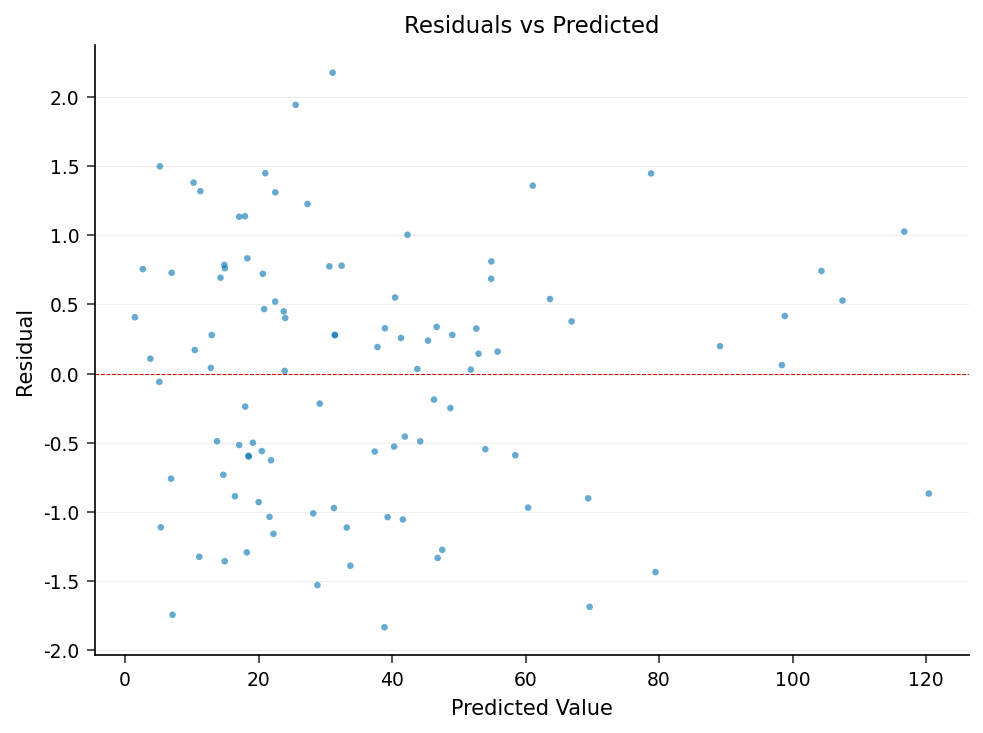

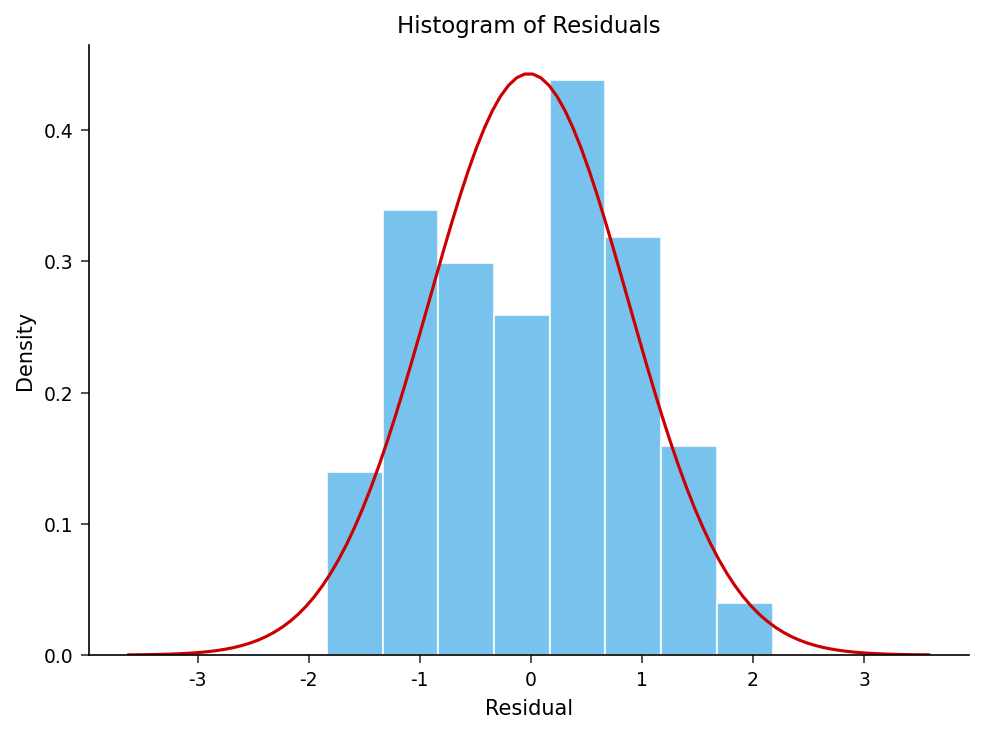

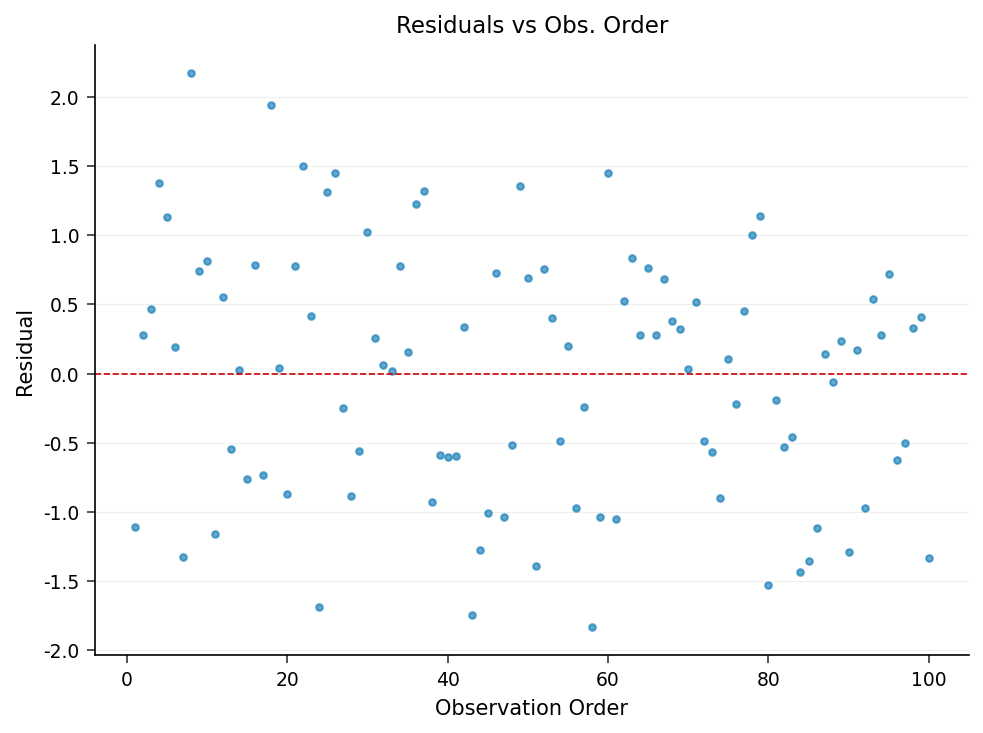

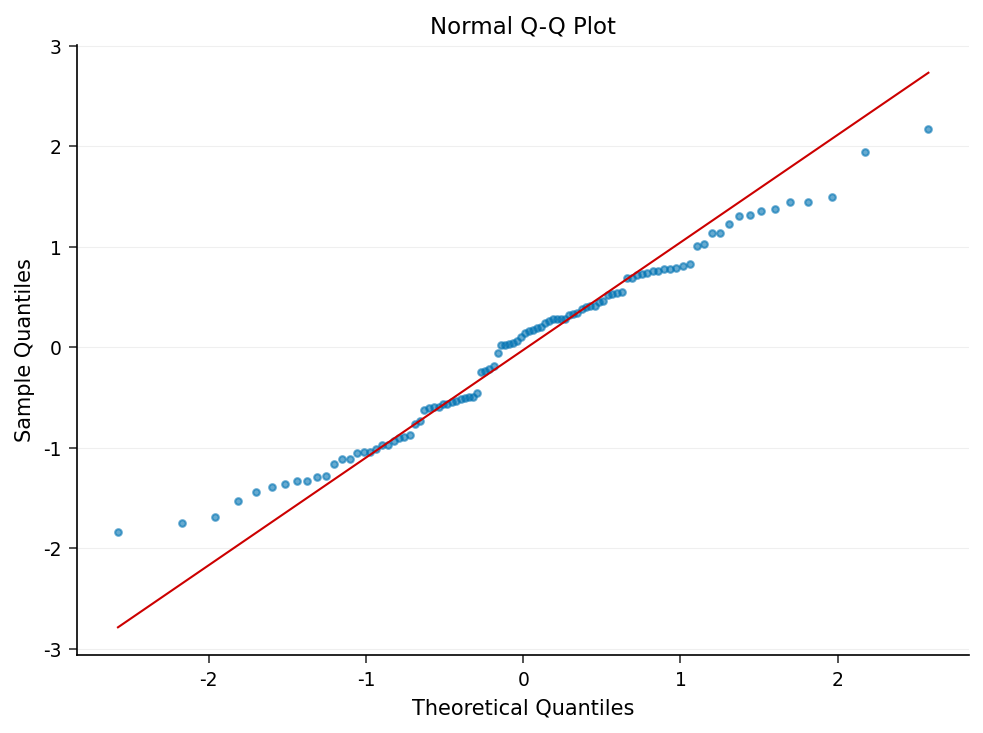

In [4]:
ODS GRAPHICS ON;
PROCEDURA GENMOD data=utility_demand;
   TŘÍDA RateClass Region;
   MODEL kwh_day = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh
                 / DIST=poisson LINK=LOG;
   ŠTÍTEK kwh_day='Denní spotřeba (kWh)' RateClass='Tarifní třída' Region='Region' hdd='Denostupně vytápění'
         cdd='Denostupně chlazení' sqft='Plocha (sqft)' occupants='Obyvatelé' solar_kw='Solár (kW)'
         appliances='Spotřebiče' price_kwh='Cena (USD/kWh)';
   NÁZEV "Poissonův model poptávky s logaritmickým spojením (PROC GENMOD)";
SPUSTIT;
ODS GRAPHICS OFF;
NÁZEV;


### Potřebují data parametr přerozptýlení?

Měřená spotřeba je často **přerozptýlená** vzhledem k čistě Poissonovu procesu. Testujeme to přímo přeformulováním s `DIST=NEGBIN`, což přidává parametr přerozptýlení, a porovnáním statistik shody s Poissonovým modelem. Pokud negativně binomický model nezlepší AIC, extra parametr si nevydělává na svou existenci a Poissonův model je lépe kalibrovanou volbou.


In [5]:
PROCEDURA GENMOD data=utility_demand;
   TŘÍDA RateClass Region;
   MODEL kwh_day = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh
                 / DIST=negbin LINK=LOG;
   ŠTÍTEK kwh_day='Denní spotřeba (kWh)' RateClass='Tarifní třída' Region='Region' hdd='Denostupně vytápění'
         cdd='Denostupně chlazení' sqft='Plocha (sqft)' occupants='Obyvatelé' solar_kw='Solár (kW)'
         appliances='Spotřebiče' price_kwh='Cena (USD/kWh)';
   NÁZEV "Negativně binomický model poptávky (PROC GENMOD)";
SPUSTIT;
NÁZEV;



                 The GENMOD Procedure                 
                  Model Information                   

Item                                             Value
----------------------  ------------------------------
Response Variable         KWH_DAY Denní spotřeba (kWh)
Distribution                                    negbin
Link Function                                      log
Number of Observations                             100

         Analysis of Maximum Likelihood Parameter Estimates         

Parameter                Estimate  Std Error  Chi-Square  Pr > ChiSq
-----------------------  --------  ---------  ----------  ----------
(Intercept)                1.9951     0.1631    149.6403      <.0001
RATECLASSIndustrial        0.5168     0.0416    154.1340      <.0001
RATECLASSResidential      -0.4794     0.0461    107.9639      <.0001
REGIONNorth                0.0904     0.0447      4.0975      0.0429
REGIONSouth                0.0747     0.0428      3.0495      0.0808
Deno


NOTE: PROC GENMOD data=utility_demand

NOTE: PROC GENMOD using R wrapper
NOTE: 
NOTE: Response Variable: KWH_DAY
NOTE: Distribution: NEGBIN
NOTE: Link Function: LOG
NOTE: Number of Observations: 100
NOTE:   Model fitted successfully with 100 observations


## Krok 5 - Přeměna vybraného modelu na skórovací artefakt

Fitovaný model je provozně užitečný pouze tehdy, pokud lze nová měřidla ohodnotit bez opětovného spuštění analýzy. **CODE FILE=** v GLMSELECT zapíše samostatný DATA-krokový výraz - fitovaný lineární prediktor a sloupec predikce `P_LOG_KWH` -, který může energetická společnost aplikovat na příchozí odečty měřidel. Vygenerujeme jej a vytiskneme zpět, aby byl nasaditelný artefakt viditelný přímo v notebooku.


In [6]:
/* Turn the selected model into a deployable scoring asset. CODE
   FILE= writes a standalone DATA-step expression (the fitted linear
   predictor and a P_LOG_KWH column) that scores new meters without
   re-fitting. We then read that file back and print it. */
PROCEDURA glmselect data=demand_log;
   TŘÍDA RateClass Region;
   MODEL log_kwh = RateClass Region hdd cdd sqft occupants
                   solar_kw appliances price_kwh noise1 noise2
                 / selection=forward(choose=SBC select=SBC stop=SBC);
   ŠTÍTEK log_kwh='Log(denní kWh)' RateClass='Tarifní třída' Region='Region' hdd='Denostupně vytápění'
         cdd='Denostupně chlazení' sqft='Plocha (sqft)' occupants='Obyvatelé' solar_kw='Solár (kW)'
         appliances='Spotřebiče' price_kwh='Cena (USD/kWh)';
   code file="score_demand.sas";
   NÁZEV "Vygenerování nasaditelného skórovacího kódu";
SPUSTIT;
NÁZEV;

data _null_;
   INFILE "score_demand.sas" DÉLKA=len;
   VSTUP line $varying200. len;
   ZAPSAT line;
SPUSTIT;


The GLMSELECT Procedure


Dependent Variable: LOG_KWH Log(denní kWh)


Number of Observations Used: 100

               Class Level Information                

    Class    Levels                             Values
---------  --------  ---------------------------------
rateclass         3  Commercial Industrial Residential
   region         3                  Coast North South

                                                       Forward Selection Summary                                                        

    Step    Action                   Effect  Number Effects In  R-Square  Adj R-Sq        AIC       AICC        BIC        SBC      C(p)
--------  --------  -----------------------  -----------------  --------  --------  ---------  ---------  ---------  ---------  --------
       1   Entered               Solár (kW)                  1    0.5367    0.5320  -120.1309  -120.0072  -123.0836  -114.9205  642.0029
       2   Entered     RATECLASS INDUSTRIAL                  2    0.7


NOTE: PROC GLMSELECT data=demand_log

NOTE: CODE FILE=score_demand.sas written.
NOTE: PROC GLMSELECT statement used.
NOTE: DATA _null_

NOTE: Reading from fileref score_demand.sas (score_demand.sas)
/* Scoring code generated by PROC GLMSELECT */
/* Response Variable: log_kwh */
.
_XBETA_ = 1.519912
+ (0.526740) * rateclass Commercial
+ (1.031530) * rateclass Industrial
+ (0.000848) * hdd
+ (0.001390) * cdd
+ (0.000149) * sqft
+ (0.089092) * occupants
+ (-0.198079) * solar_kw
+ (0.016190) * appliances;
.
/* Predicted value (identity link) */
P_LOG_KWH = _XBETA_;

NOTE: Read 15 rows from score_demand.sas.
NOTE: Wrote _null_ (15 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Krok 6 - Interpretace

**Co analýza sděluje plánovači energetické společnosti.** Dopředná selekce podle SBC a kontrola adaptivním LASSO se shodují na fyzikálně smysluplném jádru: **střešní solární panely** (`solar_kw`, první efekt, který vstoupil, se záporným koeficientem - vlastní výroba snižuje odběr ze sítě), posun **třídy sazby** (Industrial i Commercial výrazně nad Residential), **denostupně chlazení a vytápění** (`cdd`, `hdd`), **velikost nemovitosti** (`sqft`), **obsazenost** (`occupants`) a **počet spotřebičů** (`appliances`). Přesné pořadí vstupu a fitované hodnoty najdete v přehledu selekce a odhadech parametrů v krocích 2-3; dopředná selekce dospívá k osmi-efektovému modelu s R-kvadrát 0,9418.

**Odmítnutí šumu.** Dopředná selekce vylučuje *obě* uměle vložené rušivé proměnné, což potvrzuje, že kritérium odmítá falešný signál, nikoli že model přeučuje. Adaptivní LASSO ve svém AICC optimu je o něco méně úsporný - vpustí zpět jeden šumový člen s téměř nulovým koeficientem -, což je užitečná, poctivá připomínka, že různé selektory vyvažují úspornost a shodu odlišně; zde je čistší volbou SBC-zastavený dopředný model.

**Kam zmizel vliv tarifu.** Oba selektory vyřazují `price_kwh` a v Poissonově fitu GENMOD není jeho koeficient signifikantní. To je očekávané, nikoli rozporné: mezní cena se pohybuje v úzkém pásmu (její výběrový průměr je asi 0,149 dolaru/kWh s malým rozptylem), takže její příspěvek do lineárního prediktoru je malý a obtížně rozlišitelný ve vzorku 100 měřidel, i když skutečný efekt je záporný. K určení cenové elasticity by byla potřeba větší populace.

**Poisson vs. negativně binomický.** Přechod na negativně binomický model (krok 4) mění koeficienty jen málo a *zvyšuje* AIC oproti Poissonovu fitu - parametr přerozptýlení přidává složitost, kterou data nevyžadují. Pro tento vzorek je Poissonův model lépe kalibrovanou volbou; reflex vždy sáhnout po negativně binomickém modelu by stál stupeň volnosti zbytečně. Reziduální diagnostika z Poissonova fitu (reziduály vůči predikovaným hodnotám a normální Q-Q graf) neukazuje žádnou hrubou odchylku od předpokladů modelu.

**Nasaditelný model.** Vygenerovaný `score_demand.sas` (krok 5) přeměňuje vybranou strukturu na samostatný skórovací výraz: nová měřidla lze ohodnotit na očekávanou denní poptávku a velká predikční rezidua se stávají kandidátním signálem pro poruchy měřidla, nemodelované chování nebo krádež - pracovní postup, který by energetický analytický tým nasadil do provozu.
